In [4]:
import os
import pandas as pd
from hashlib import md5
from PIL import Image

# Data Cleaning

In [15]:
noisy_data_path = "/srv/defectDetectionDataset/multiclassClassification/noisy"
clean_data_path = "/srv/defectDetectionDataset/multiclassClassification/full_clean"

artifacts_path = "/home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts"
log_path = "/home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/changelog.txt"

In [103]:
noisy_images = []

extensions = [".png", ".jpg", ".jpeg"]

for dirpath, dirnames, filenames in os.walk(noisy_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            noisy_images.append({"image_id": image_id, "file_path": file_path, "label": label})


clean_images = []

for dirpath, dirnames, filenames in os.walk(clean_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            clean_images.append({"image_id": image_id, "file_path": file_path, "label": label})

noisy_df = pd.DataFrame(noisy_images)
clean_df = pd.DataFrame(clean_images)

In [104]:
noisy_df.to_csv(os.path.join(artifacts_path, "noisy_images.csv"), index=False)
clean_df.to_csv(os.path.join(artifacts_path, "clean_images.csv"), index=False)

In [105]:
# Get all removed images
removed_df = noisy_df[~noisy_df['image_id'].isin(clean_df['image_id'])]

print(f"Number of noisy images: {len(noisy_df)}")
print(f"Number of clean images: {len(clean_df)}")
print(f"Number of removed images: {len(removed_df)}")

removed_df.to_csv(os.path.join(artifacts_path, "removed_images.csv"), index=False)

Number of noisy images: 4944
Number of clean images: 4521
Number of removed images: 389


In [18]:
log = open(log_path, "a")

def log_change(filename, old_label, new_label, reason):
    with open(log_path, "a") as log_file:
        log_file.write(f"{filename}, {old_label}, {new_label}, {reason}\n")

for _, row in removed_df.iterrows():
    log_change(row['file_path'], row['label'], "removed", "empty or too bad quality")

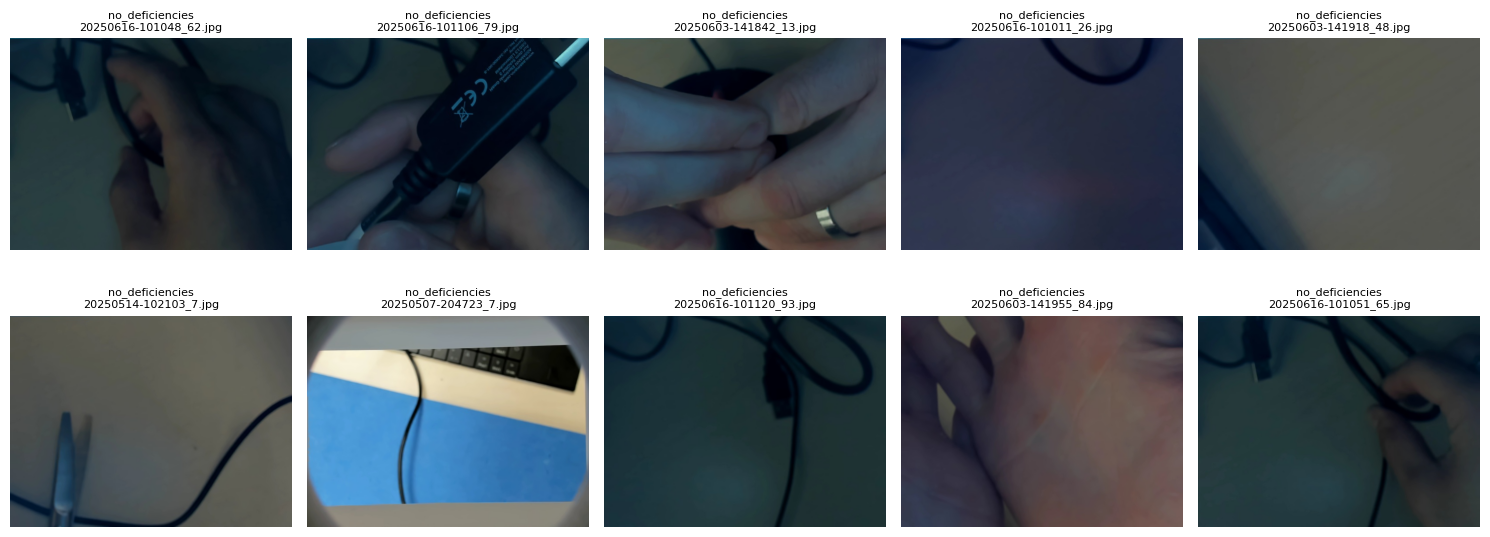

In [12]:
import matplotlib.pyplot as plt

samples = removed_df.sample(n=10, random_state=42)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(row['file_path'])
    axes[idx].imshow(img)
    axes[idx].set_title(f"{row['label']}\n{os.path.basename(row['file_path'])}", fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, "removed_samples.png"), dpi=150, bbox_inches='tight')
plt.show()

## Find exact duplicates by file hashes

In [27]:
duplicates_ids = clean_df[clean_df.duplicated(subset=['image_id'], keep="first")]['image_id'].unique()

print(f"Number of duplicate images in clean dataset: {len(duplicates_ids)}")

Number of duplicate images in clean dataset: 0


## Find near duplicates with pretrained model

In [28]:
import torch
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
import numpy as np
import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load MobileNetV3-Large with pretrained weights
weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
model = models.mobilenet_v3_large(weights=weights)
model.to(device)

# Define transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = v2.Compose([
    v2.Resize(480, antialias=True),
    v2.CenterCrop(480),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

model.eval()

clean_embeddings = []

@torch.no_grad()
def get_mobilenet_embedding(model, img_tensor):
    """Extract features from MobileNetV3 before classifier"""
    feats = model.features(img_tensor)
    feats = model.avgpool(feats)
    feats = torch.flatten(feats, 1)
    return torch.nn.functional.normalize(feats, dim=1)

for idx, row in clean_df.iterrows():
    img = Image.open(row["file_path"]).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    embedding = get_mobilenet_embedding(model, img_tensor)
    embedding = embedding.cpu().numpy().flatten()
    
    clean_embeddings.append({
        "image_id": row["image_id"],
        "embedding": embedding
    })
    
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(clean_df)} clean images")

# Save embeddings
embeddings_array = np.array([e["embedding"] for e in clean_embeddings])
image_ids = [e["image_id"] for e in clean_embeddings]

np.save(os.path.join(artifacts_path, "clean_image_embeddings.npy"), embeddings_array)
pd.DataFrame({"image_id": image_ids}).to_csv(os.path.join(artifacts_path, "clean_image_embeddings_ids.csv"), index=False)

print(f"Generated embeddings for {len(clean_embeddings)} clean images")
print(f"Embedding shape: {embeddings_array.shape}")

Processed 100/4521 clean images
Processed 200/4521 clean images
Processed 300/4521 clean images
Processed 400/4521 clean images
Processed 500/4521 clean images
Processed 600/4521 clean images
Processed 700/4521 clean images
Processed 800/4521 clean images
Processed 900/4521 clean images
Processed 1000/4521 clean images
Processed 1100/4521 clean images
Processed 1200/4521 clean images
Processed 1300/4521 clean images
Processed 1400/4521 clean images
Processed 1500/4521 clean images
Processed 1600/4521 clean images
Processed 1700/4521 clean images
Processed 1800/4521 clean images
Processed 1900/4521 clean images
Processed 2000/4521 clean images
Processed 2100/4521 clean images
Processed 2200/4521 clean images
Processed 2300/4521 clean images
Processed 2400/4521 clean images
Processed 2500/4521 clean images
Processed 2600/4521 clean images
Processed 2700/4521 clean images
Processed 2800/4521 clean images
Processed 2900/4521 clean images
Processed 3000/4521 clean images
Processed 3100/4521

In [29]:
embeddings_dict = {image_id: embeddings_array[idx] for idx, image_id in enumerate(image_ids)}

import faiss

dimension = embeddings_array.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_array)
print(f"FAISS index built with {index.ntotal} vectors of dimension {dimension}")

# search for 20 nearest neighbors
k = 20
D, I = index.search(embeddings_array, k)
D, I = torch.from_numpy(D), torch.from_numpy(I)#
# D: distances, I: indices of nearest neighbors

FAISS index built with 4521 vectors of dimension 960


In [30]:
high_threshold = 0.99
medium_threshold = 0.92
low_threshold = 0.85

# Calculate cosine similarity from L2 distances
# Convert L2 distance to cosine similarity: similarity = 1 - (L2_distance^2 / 2)
similarities = 1 - (D ** 2 / 2)

# Create similarity pairs with image IDs
similarity_pairs = []
for i in range(len(similarities)):
    for j in range(1, k):  # Skip first neighbor (itself)
        img_id_1 = image_ids[i]
        img_id_2 = image_ids[I[i][j].item()]
        sim_score = similarities[i][j].item()
        similarity_pairs.append({
            "image_id_1": img_id_1,
            "image_id_2": img_id_2,
            "similarity": sim_score
        })

similarity_df = pd.DataFrame(similarity_pairs)

# Save all similarity pairs to CSV
similarity_df.to_csv(os.path.join(artifacts_path, "clean_similarity_pairs.csv"), index=False)
print(f"Saved {len(similarity_df)} similarity pairs to {os.path.join(artifacts_path, 'clean_similarity_pairs.csv')}")

# Filter by thresholds
high_sim = similarity_df[similarity_df["similarity"] >= high_threshold]
medium_sim = similarity_df[(similarity_df["similarity"] >= medium_threshold) & 
                           (similarity_df["similarity"] < high_threshold)]
low_sim = similarity_df[(similarity_df["similarity"] >= low_threshold) & 
                        (similarity_df["similarity"] < medium_threshold)]

print(f"High similarity pairs (>= {high_threshold}): {len(high_sim)}")
print(f"Medium similarity pairs ({medium_threshold} - {high_threshold}): {len(medium_sim)}")
print(f"Low similarity pairs ({low_threshold} - {medium_threshold}): {len(low_sim)}")

Saved 85899 similarity pairs to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/clean_similarity_pairs.csv
High similarity pairs (>= 0.99): 8278
Medium similarity pairs (0.92 - 0.99): 64429
Low similarity pairs (0.85 - 0.92): 10857


In [31]:
best_treshold = float(0.995)

In [35]:
# Build near-duplicate clusters using the best_threshold and the full similarity pairs file.
# Clusters = connected components in a graph where an edge exists if similarity >= best_threshold.

# Use the threshold found earlier (best_threshold is already defined in the notebook)
thr = best_treshold

# Choose graph construction: "mutual" or "transitive"
edge_mode = "mutual"  # "mutual" = mutual k-NN edges, "transitive" = all edges >= thr

# Keep only edges with similarity >= threshold
edges_df = similarity_df[similarity_df["similarity"] >= thr][
    ["image_id_1", "image_id_2", "similarity"]
].copy()

print(f"Threshold: {thr:.6f}")
print(f"Edges (similarity >= threshold): {len(edges_df):,}")
print(f"Edge mode: {edge_mode}")

if edge_mode == "mutual":
    # --- Mutual k-NN edges ---
    # An undirected edge (a,b) is kept only if both (a->b) and (b->a) exist
    pair_sim = {(r.image_id_1, r.image_id_2): float(r.similarity) for r in edges_df.itertuples(index=False)}

    mutual_edges = []
    seen = set()
    for (a, b), sim_ab in pair_sim.items():
        if (b, a) not in pair_sim:
            continue
        key = (a, b) if a <= b else (b, a)
        if key in seen:
            continue
        sim_ba = pair_sim[(b, a)]
        mutual_edges.append((key[0], key[1], min(sim_ab, sim_ba)))
        seen.add(key)

    print(f"Mutual edges: {len(mutual_edges):,}")
    edge_list = mutual_edges
elif edge_mode == "transitive":
    # --- Transitive edges (all edges >= threshold) ---
    edge_list = [(r.image_id_1, r.image_id_2, float(r.similarity)) for r in edges_df.itertuples(index=False)]
    print(f"Transitive edges: {len(edge_list):,}")
else:
    raise ValueError(f"Unknown edge_mode: {edge_mode}")

# --- Graph-based connected components ---
# Build adjacency list
graph = {}
for a, b, sim in edge_list:
    if a not in graph:
        graph[a] = set()
    if b not in graph:
        graph[b] = set()
    graph[a].add(b)
    graph[b].add(a)

# Find connected components via DFS/BFS
visited = set()
clusters = []
for node in graph:
    if node in visited:
        continue
    stack = [node]
    component = []
    visited.add(node)
    while stack:
        cur = stack.pop()
        component.append(cur)
        for nbr in graph[cur]:
            if nbr not in visited:
                visited.add(nbr)
                stack.append(nbr)
    if len(component) >= 2:
        clusters.append(sorted(component))

clusters.sort(key=len, reverse=True)

print(f"Clusters (size >= 2): {len(clusters):,}")
if clusters:
    print(f"Largest cluster size: {len(clusters[0])}")

# Create membership table
membership_rows = []
for cid, members in enumerate(clusters):
    for image_id in members:
        membership_rows.append({"cluster_id": cid, "image_id": image_id, "threshold": thr, "edge_mode": edge_mode})

clusters_df = pd.DataFrame(membership_rows)

# Add manifest metadata if available
if not clean_df.empty and not clusters_df.empty:
    clusters_df = clusters_df.merge(clean_df, on="image_id", how="left")

# Save outputs
out_membership = os.path.join(artifacts_path, f"near_duplicate_clusters_{edge_mode}_thr_{thr:.3f}.csv")
clusters_df.to_csv(out_membership, index=False)
print(f"Saved cluster membership to: {out_membership}")

Threshold: 0.995000
Edges (similarity >= threshold): 3,418
Edge mode: mutual
Mutual edges: 1,709
Clusters (size >= 2): 517
Largest cluster size: 17
Saved cluster membership to: /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/near_duplicate_clusters_mutual_thr_0.995.csv


In [53]:
# --- Cluster-aware dataset split (0.7 / 0.15 / 0.15) ---
# Strategy: place non-clustered (singleton) images into val/test first,
# then fill remaining val/test from clustered images, and put the rest in train.

import numpy as np

all_ids = clean_df["image_id"].astype(str).unique().tolist()

clustered_ids = set(clusters_df["image_id"].astype(str).unique())
singleton_ids = [i for i in all_ids if i not in clustered_ids]
clustered_only_ids = [i for i in all_ids if i in clustered_ids]

n_total = len(all_ids)
if n_total == 0:
    raise ValueError("No images found for splitting.")

n_train = int(round(0.70 * n_total))
n_val = int(round(0.15 * n_total))
n_test = n_total - n_train - n_val

rng = np.random.default_rng(42)
rng.shuffle(singleton_ids)
rng.shuffle(clustered_only_ids)

val_ids = []
test_ids = []
train_ids = []

# Fill val/test from singletons first
val_ids.extend(singleton_ids[:n_val])
remaining_singletons = singleton_ids[n_val:]

needed_test = n_test
available_for_test = remaining_singletons
if len(available_for_test) >= needed_test:
    test_ids.extend(available_for_test[:needed_test])
    remaining_singletons = available_for_test[needed_test:]
else:
    test_ids.extend(available_for_test)
    remaining_singletons = []

# Fill any remaining val/test slots from clustered images
remaining_val_slots = n_val - len(val_ids)
remaining_test_slots = n_test - len(test_ids)

if remaining_val_slots > 0:
    val_ids.extend(clustered_only_ids[:remaining_val_slots])
    clustered_only_ids = clustered_only_ids[remaining_val_slots:]

if remaining_test_slots > 0:
    test_ids.extend(clustered_only_ids[:remaining_test_slots])
    clustered_only_ids = clustered_only_ids[remaining_test_slots:]

# Put the rest into train
train_ids = clustered_only_ids + remaining_singletons

# Sanity checks
assert len(set(train_ids) & set(val_ids)) == 0
assert len(set(train_ids) & set(test_ids)) == 0
assert len(set(val_ids) & set(test_ids)) == 0
assert len(train_ids) + len(val_ids) + len(test_ids) == n_total

# Build split DataFrame
split_rows = []
for i in train_ids:
    split_rows.append({"image_id": i, "split": "train"})
for i in val_ids:
    split_rows.append({"image_id": i, "split": "val"})
for i in test_ids:
    split_rows.append({"image_id": i, "split": "test"})

split_df = pd.DataFrame(split_rows)

# Merge paths/labels for convenience
split_df = split_df.merge(clean_df, on="image_id", how="left")

out_path = os.path.join(artifacts_path, "cluster_aware_split_70_15_15.csv")
split_df.to_csv(out_path, index=False)

# Report composition

def count_clustered(ids):
    return sum(1 for i in ids if i in clustered_ids)

print(f"Total images: {n_total}")
print(f"Train/Val/Test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")
print(
    "Clustered in splits (train/val/test): "
    f"{count_clustered(train_ids)}/{count_clustered(val_ids)}/{count_clustered(test_ids)}"
)
print(
    "Singletons in splits (train/val/test): "
    f"{len(train_ids)-count_clustered(train_ids)}/"
    f"{len(val_ids)-count_clustered(val_ids)}/"
    f"{len(test_ids)-count_clustered(test_ids)}"
)
print(f"Saved split manifest to {out_path}")

Total images: 4521
Train/Val/Test: 3165/678/678
Clustered in splits (train/val/test): 1653/0/0
Singletons in splits (train/val/test): 1512/678/678
Saved split manifest to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/cluster_aware_split_70_15_15.csv


In [57]:
# --- Materialize dataset to data/surface_clustered ---
# Uses the split manifest created in the previous cell.

from pathlib import Path
from shutil import copy2

out_root = Path("/srv/defectDetectionDataset/multiclassClassification/full_clean_clustered")

required_cols = {"file_path", "label", "split"}
missing_cols = required_cols - set(split_df.columns)
if missing_cols:
    raise ValueError(f"Split manifest missing columns: {missing_cols}")

# Create directories
for split in ["train", "val", "test"]:
    (out_root / split).mkdir(parents=True, exist_ok=True)

# Copy images into split/label folders
copied = 0
missing = 0
for row in split_df.itertuples(index=False):
    src = Path(row.file_path)
    if not src.exists():
        missing += 1
        continue
    dest_dir = out_root / row.split / row.label
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / src.name
    copy2(src, dest_path)
    copied += 1

print(f"Copied {copied} images to {out_root}")
if missing:
    print(f"Skipped {missing} missing files")

Copied 4521 images to /srv/defectDetectionDataset/multiclassClassification/full_clean_clustered


## Cleaned clustered dataset

In [83]:
sec_cleaned_data_path = "/srv/defectDetectionDataset/multiclassClassification/full_clean_clustered_cleaned"

In [77]:
sec_cleaned_images = []

for dirpath, dirnames, filenames in os.walk(sec_cleaned_data_path):
    split = dirpath.split(os.sep)[-2]  # get split from path
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            sec_cleaned_images.append({"image_id": image_id, "file_path": file_path, "label": label, "split": split})

sec_clean_df = pd.DataFrame(sec_cleaned_images)

In [81]:
sec_clean_df.to_csv(os.path.join(artifacts_path, "sec_cleaned_images.csv"), index=False)

In [78]:
# which files were moved from test or val to train during second cleaning
moved_files = sec_clean_df[
    (sec_clean_df['split'] == 'train') &
    (sec_clean_df['image_id'].isin(split_df[split_df['split'].isin(['val', 'test'])]['image_id']))
]

print(f"Number of files moved from val/test to train during second cleaning: {len(moved_files)}")

for _, row in moved_files.iterrows():
    log_change(row['file_path'], row['label'], "train", "moved from val/test to train during second cleaning")

Number of files moved from val/test to train during second cleaning: 4


In [79]:
# which files were moved from test or val to train during second cleaning
moved_files = sec_clean_df[
    (sec_clean_df['split'].isin(['val', 'test'])) &
    (sec_clean_df['image_id'].isin(split_df[split_df['split'].isin(['train'])]['image_id']))
]

print(f"Number of files moved from train to val/test during second cleaning: {len(moved_files)}")
    
for _, row in moved_files.iterrows():
    log_change(row['file_path'], row['label'], "train", "moved from val/test to train during second cleaning")

Number of files moved from train to val/test during second cleaning: 7


In [80]:
# check if any cluster is split across train/val/test in the second cleaned dataset
clustered_split_issues = []

# Check which images are in train, but belong to clusters that also have images in val/test
for cid, group in clusters_df.groupby("cluster_id"):
    cluster_image_ids = set(group["image_id"].astype(str).unique())
    sec_cluster_images = sec_clean_df[sec_clean_df["image_id"].astype(str).isin(cluster_image_ids)]
    splits_in_cluster = sec_cluster_images["split"].unique()
    if len(splits_in_cluster) > 1:
        clustered_split_issues.append({
            "cluster_id": cid,
            "image_ids": list(cluster_image_ids),
            "splits": list(splits_in_cluster)
        })

print(f"Number of clusters split across train/val/test in second cleaned dataset: {len(clustered_split_issues)}")

# print the image paths of the images, that are in the split clusters
for issue in clustered_split_issues:
    cid = issue["cluster_id"]
    splits = issue["splits"]
    print(f"Cluster ID {cid} is split across splits: {splits}")
    cluster_image_ids = issue["image_ids"]
    sec_cluster_images = sec_clean_df[sec_clean_df["image_id"].astype(str).isin(cluster_image_ids)]
    for _, row in sec_cluster_images.iterrows():
        print(f" - {row['file_path']} in split {row['split']}")

Number of clusters split across train/val/test in second cleaned dataset: 0


## Add the new images

In [85]:
cleaned_with_new = "/srv/defectDetectionDataset/multiclassClassification/full_clean_clustered_new"

In [86]:
cleaned_with_new_images = []

for dirpath, dirnames, filenames in os.walk(cleaned_with_new):
    split = dirpath.split(os.sep)[-2]  # get split from path
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            cleaned_with_new_images.append({"image_id": image_id, "file_path": file_path, "label": label, "split": split})

cleaned_with_new_df = pd.DataFrame(cleaned_with_new_images)

In [88]:
# Find newly added images by comparing cleaned_with_new_df with sec_clean_df
new_images = cleaned_with_new_df[~cleaned_with_new_df['image_id'].isin(sec_clean_df['image_id'])]

print(f"Number of newly added images: {len(new_images)}")
print(f"Distribution across splits:")
print(new_images['split'].value_counts())
print()

# Log each new image
for _, row in new_images.iterrows():
    log_change(row['file_path'], "new", row['label'], f"added to {row['split']} split")

print(f"Logged {len(new_images)} new images to {log_path}")

Number of newly added images: 764
Distribution across splits:
split
train    339
test     287
val      138
Name: count, dtype: int64

Logged 764 new images to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/changelog.txt


## Create a noisy dataset with clean test and val set.

In [ ]:
from pathlib import Path

# Create noisy dataset with clean val and test splits

noisy_clean_split_path = Path("/srv/defectDetectionDataset/multiclassClassification/noisy_clean_split_new")

In [ ]:
import shutil

overwrite = True   # set False to prevent deleting an existing output folder
dry_run = False    # set True to only compute counts / manifest without copying files

out_root = Path(noisy_clean_split_path)

if out_root.exists() and any(out_root.iterdir()):
    if not overwrite:
        raise RuntimeError(
            f"{out_root} already exists and is not empty. "
            "Set overwrite=True to delete and recreate it."
        )
    if not dry_run:
        shutil.rmtree(out_root)

out_root.mkdir(parents=True, exist_ok=True)

# Build indexes
clean_ref = cleaned_with_new_df.copy()
noisy_ref = noisy_df.copy()

# Basic validation
required_clean_cols = {"image_id", "file_path", "label", "split"}
missing_clean_cols = required_clean_cols - set(clean_ref.columns)
if missing_clean_cols:
    raise ValueError(f"cleaned_with_new_df missing columns: {missing_clean_cols}")

required_noisy_cols = {"image_id", "file_path", "label"}
missing_noisy_cols = required_noisy_cols - set(noisy_ref.columns)
if missing_noisy_cols:
    raise ValueError(f"noisy_df missing columns: {missing_noisy_cols}")

# Ensure string IDs
clean_ref["image_id"] = clean_ref["image_id"].astype(str)
noisy_ref["image_id"] = noisy_ref["image_id"].astype(str)

# Detect duplicates by ID
n_clean_dupes = int(clean_ref.duplicated(subset=["image_id"]).sum())
n_noisy_dupes = int(noisy_ref.duplicated(subset=["image_id"]).sum())
if n_clean_dupes:
    print(f"[WARN] cleaned_with_new_df has {n_clean_dupes} duplicate image_id rows; keeping first occurrence.")
if n_noisy_dupes:
    print(f"[WARN] noisy_df has {n_noisy_dupes} duplicate image_id rows; keeping first occurrence.")

clean_by_id = clean_ref.drop_duplicates(subset=["image_id"], keep="first").set_index("image_id")
noisy_by_id = noisy_ref.drop_duplicates(subset=["image_id"], keep="first").set_index("image_id")

clean_ids = set(clean_by_id.index)
noisy_ids = set(noisy_by_id.index)

removed_from_noisy = noisy_ids - clean_ids
missing_in_noisy = clean_ids - noisy_ids
common = noisy_ids & clean_ids

print(f"Noisy images total: {len(noisy_ids)}")
print(f"Clean reference images total: {len(clean_ids)}")
print(f"Will exclude from noisy (not in cleaned_with_new_df): {len(removed_from_noisy)}")
print(f"Will add from cleaned (missing in noisy): {len(missing_in_noisy)}")
print(f"Present in both: {len(common)}")

valid_splits = {"train", "val", "test"}
bad_splits = sorted(set(clean_by_id["split"]) - valid_splits)
if bad_splits:
    print(f"[WARN] Unexpected split values in cleaned_with_new_df: {bad_splits}")

def safe_dest_path(dest_dir: Path, image_id: str, src_name: str) -> Path:
    # Avoid name collisions by prefixing with a short hash; add suffix if still colliding.
    base = f"{image_id[:8]}_{src_name}"
    candidate = dest_dir / base
    if not candidate.exists():
        return candidate
    stem, dot, ext = base.partition(".")
    for i in range(1, 1000):
        alt = dest_dir / f"{stem}__{i}.{ext}" if dot else dest_dir / f"{stem}__{i}"
        if not alt.exists():
            return alt
    raise RuntimeError(f"Too many filename collisions under {dest_dir}")

rows = []
copied = 0
train_used_noisy = 0
train_used_clean_fallback = 0
valtest_used_clean = 0
skipped_missing_src = 0

for image_id, clean_rec in clean_by_id.to_dict("index").items():
    split = clean_rec["split"]
    clean_label = clean_rec["label"]
    clean_src = Path(clean_rec["file_path"])

    src_kind = None
    src = None
    out_label = None

    if split in {"val", "test"}:
        # Val/Test are always clean (image + label).
        src = clean_src
        src_kind = "clean_valtest"
        out_label = clean_label
        valtest_used_clean += 1
    else:
        # Train: prefer the noisy version + noisy label to keep label-noise in train.
        if image_id in noisy_by_id.index:
            noisy_row = noisy_by_id.loc[image_id]
            src = Path(noisy_row["file_path"])
            src_kind = "noisy_train"
            out_label = noisy_row["label"]
            train_used_noisy += 1
        else:
            # New images not present in noisy: fall back to clean image + clean label.
            src = clean_src
            src_kind = "clean_train_fallback"
            out_label = clean_label
            train_used_clean_fallback += 1

    target_dir = out_root / split / str(out_label)
    target_path = safe_dest_path(target_dir, image_id=image_id, src_name=src.name)

    if not src.exists():
        skipped_missing_src += 1
        rows.append({
            "image_id": image_id,
            "split": split,
            "clean_label": clean_label,
            "out_label": out_label,
            "src_kind": src_kind,
            "src_path": str(src),
            "dest_path": str(target_path),
            "status": "missing_src",
        })
        continue

    if not dry_run:
        target_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, target_path)

    copied += 1
    rows.append({
        "image_id": image_id,
        "split": split,
        "clean_label": clean_label,
        "out_label": out_label,
        "src_kind": src_kind,
        "src_path": str(src),
        "dest_path": str(target_path),
        "status": "copied" if not dry_run else "planned",
    })

manifest_df = pd.DataFrame(rows)
manifest_out = os.path.join(artifacts_path, "noisy_clean_split_manifest.csv")
manifest_df.to_csv(manifest_out, index=False)

print("\n" + "=" * 80)
print(f"Created dataset at: {out_root}")
print(f"Manifest written to: {manifest_out}")
print(f"Images copied: {copied}")
print(f"Train sources: noisy={train_used_noisy}, clean_fallback={train_used_clean_fallback}")
print(f"Val/Test sources: clean={valtest_used_clean}")
if skipped_missing_src:
    print(f"[WARN] Missing source files skipped: {skipped_missing_src}")

print("\nSplit distribution (from manifest):")
print(manifest_df[manifest_df["status"].isin(["copied", "planned"])]["split"].value_counts(dropna=False))

print("\nTrain label source check (src_kind counts):")
print(manifest_df[manifest_df["split"] == "train"]["src_kind"].value_counts(dropna=False))

[WARN] noisy_df has 35 duplicate image_id rows; keeping first occurrence.
Noisy images total: 4909
Clean reference images total: 5285
Will exclude from noisy (not in cleaned_with_new_df): 388
Will add from cleaned (missing in noisy): 764
Present in both: 4521

Created dataset at: /srv/defectDetectionDataset/multiclassClassification/noisy_clean_split_new
Manifest written to: /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/noisy_clean_split_manifest.csv
Images copied: 5285
Train sources: noisy=3162, clean_fallback=339
Val/Test sources: clean=1784

Split distribution (from manifest):
split
train    3501
test      967
val       817
Name: count, dtype: int64

Train label source check (src_kind counts):
src_kind
noisy_train             3162
clean_train_fallback     339
Name: count, dtype: int64


## Create binary classification set

In [107]:
from pathlib import Path
from shutil import copy2
import shutil
import os
import pandas as pd

# Binary datasets: defects vs no_defects
src_noisy_multiclass = Path("/srv/defectDetectionDataset/multiclassClassification/noisy_clean_split_new")
src_clean_multiclass = Path("/srv/defectDetectionDataset/multiclassClassification/full_clean_clustered_new")
binary_root = Path("/srv/defectDetectionDataset/binaryClassification")

overwrite = True
dry_run = False

img_exts = {".png", ".jpg", ".jpeg"}
valid_splits = {"train", "val", "test"}
negative_label = "no_defects"
positive_label = "defects"

def iter_images(src_root: Path):
    for split_dir in src_root.iterdir():
        if not split_dir.is_dir():
            continue
        split = split_dir.name
        if split not in valid_splits:
            continue
        for class_dir in split_dir.iterdir():
            if not class_dir.is_dir():
                continue
            original_label = class_dir.name
            for p in class_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in img_exts:
                    yield split, original_label, p

def safe_copy(src: Path, dest_dir: Path, stem_prefix: str):
    dest_dir.mkdir(parents=True, exist_ok=True)
    base = f"{stem_prefix}{src.name}"
    dest = dest_dir / base
    if not dest.exists():
        if not dry_run:
            copy2(src, dest)
        return dest
    # Collision: append counter
    stem, dot, ext = src.name.partition(".")
    for i in range(1, 10000):
        alt_name = f"{stem_prefix}{stem}__{i}.{ext}" if dot else f"{stem_prefix}{stem}__{i}"
        alt = dest_dir / alt_name
        if not alt.exists():
            if not dry_run:
                copy2(src, alt)
            return alt
    raise RuntimeError(f"Too many collisions in {dest_dir}")

def build_binary_dataset(src_root: Path, out_name: str):
    out_root = binary_root / out_name
    if out_root.exists() and overwrite and not dry_run:
        shutil.rmtree(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    records = []
    counts = {s: {positive_label: 0, negative_label: 0} for s in valid_splits}
    missing_split_dirs = [s for s in valid_splits if not (src_root / s).exists()]
    if missing_split_dirs:
        print(f"[WARN] {src_root} missing split dirs: {missing_split_dirs}")

    for split, original_label, src_path in iter_images(src_root):
        bin_label = negative_label if original_label == negative_label else positive_label
        dest_dir = out_root / split / bin_label
        # Prefix with original label to keep traceability + reduce collisions
        dest_path = safe_copy(src_path, dest_dir, stem_prefix=f"{original_label}__")
        counts[split][bin_label] += 1
        records.append({
            "dataset": out_name,
            "split": split,
            "original_label": original_label,
            "binary_label": bin_label,
            "src_path": str(src_path),
            "dest_path": str(dest_path),
        })

    manifest = pd.DataFrame(records)
    manifest_path = out_root / "manifest.csv"
    if not dry_run:
        manifest.to_csv(manifest_path, index=False)

    print("\n" + "=" * 80)
    print(f"Binary dataset created: {out_root}")
    print(f"Source: {src_root}")
    print(f"Manifest: {manifest_path}")
    for split in sorted(valid_splits):
        print(f"{split}: {positive_label}={counts[split][positive_label]}, {negative_label}={counts[split][negative_label]}")
    print(f"Total: {len(records)}")
    return out_root, manifest_path

# Create two binary datasets: one derived from noisy_clean_split_new, one from full_clean_clustered_new
binary_root.mkdir(parents=True, exist_ok=True)

noisy_out, noisy_manifest = build_binary_dataset(src_noisy_multiclass, out_name="noisy_clean_split_new")
clean_out, clean_manifest = build_binary_dataset(src_clean_multiclass, out_name="full_clean_clustered_new")


Binary dataset created: /srv/defectDetectionDataset/binaryClassification/noisy_clean_split_new
Source: /srv/defectDetectionDataset/multiclassClassification/noisy_clean_split_new
Manifest: /srv/defectDetectionDataset/binaryClassification/noisy_clean_split_new/manifest.csv
test: defects=829, no_defects=138
train: defects=2276, no_defects=1225
val: defects=635, no_defects=182
Total: 5285

Binary dataset created: /srv/defectDetectionDataset/binaryClassification/full_clean_clustered_new
Source: /srv/defectDetectionDataset/multiclassClassification/full_clean_clustered_new
Manifest: /srv/defectDetectionDataset/binaryClassification/full_clean_clustered_new/manifest.csv
test: defects=829, no_defects=138
train: defects=2818, no_defects=683
val: defects=635, no_defects=182
Total: 5285
